In [15]:
import pandas as pd

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="dark")
plt.rcParams["figure.figsize"] = (8, 5)


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/MyDrive/car-insurance-claim-prediction")


In [3]:
!pwd


/content/drive/MyDrive/car-insurance-claim-prediction


In [6]:
train = pd.read_csv("data/raw/train.csv")

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

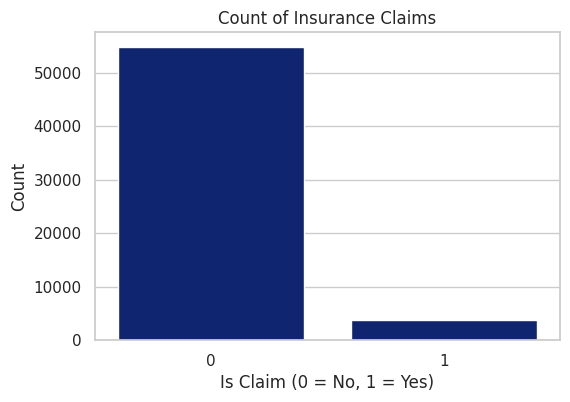

In [35]:


plt.figure(figsize=(6,4))
sns.countplot(x='is_claim', data=train)
plt.title("Count of Insurance Claims")
plt.xlabel("Is Claim (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


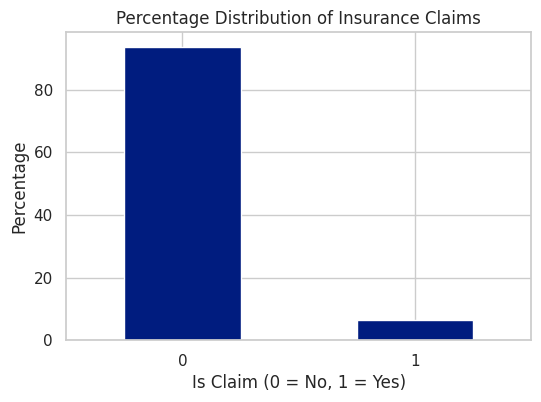

In [36]:
claim_pct = train['is_claim'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
claim_pct.plot(kind='bar')
plt.title("Percentage Distribution of Insurance Claims")
plt.xlabel("Is Claim (0 = No, 1 = Yes)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


# ***Age Related***

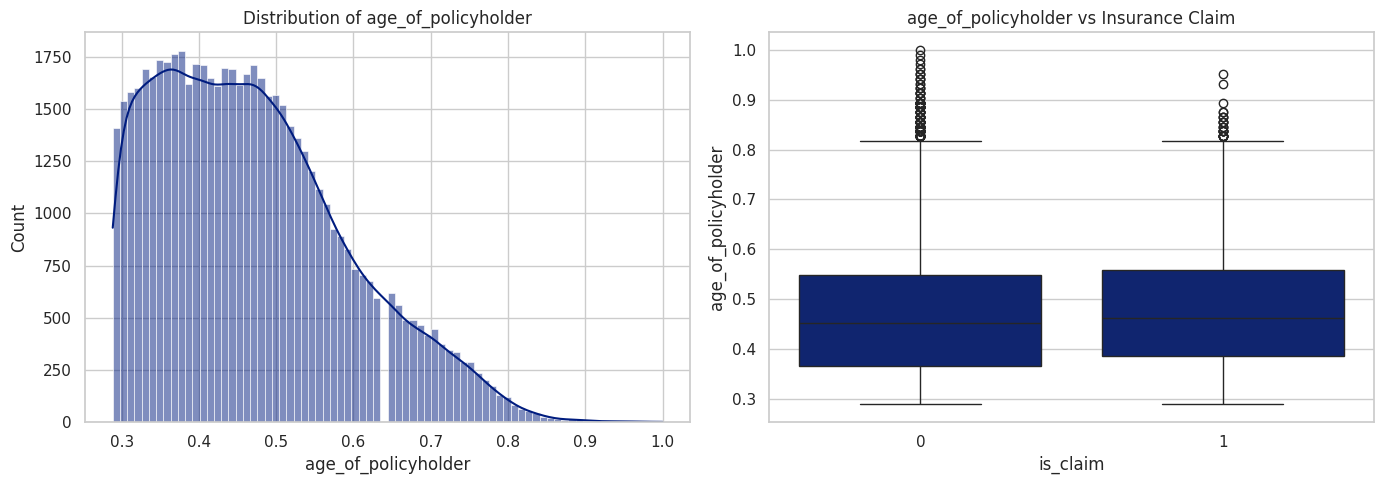

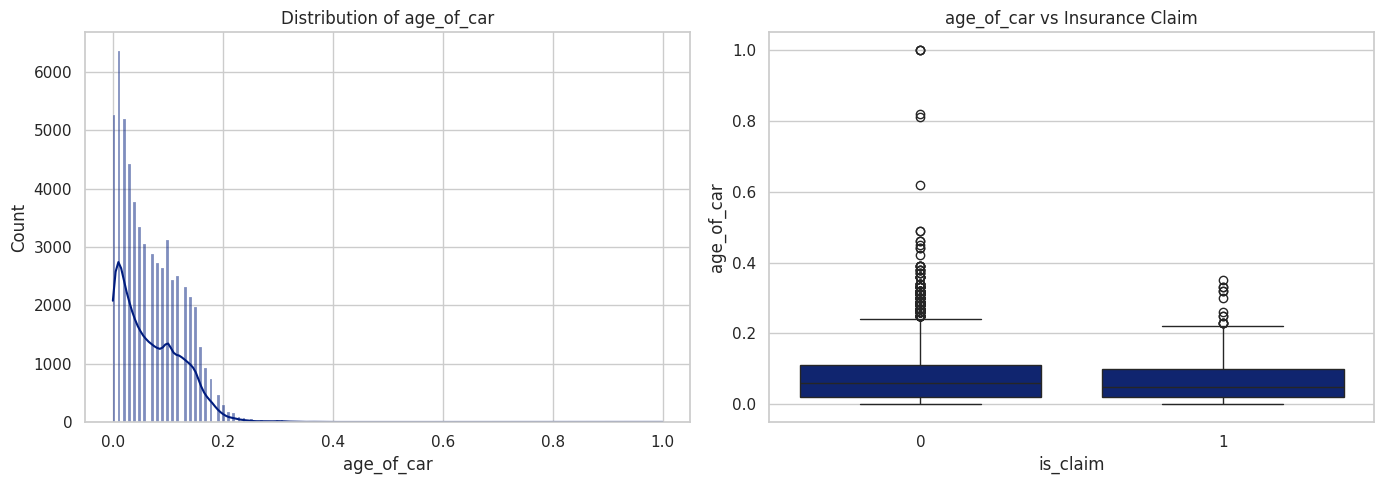

In [38]:
for col in ['age_of_policyholder', 'age_of_car']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(train[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x='is_claim', y=col, data=train, ax=axes[1])
    axes[1].set_title(f"{col} vs Insurance Claim")

    plt.tight_layout()
    plt.show()


# ***Vehicle & city characteristics***



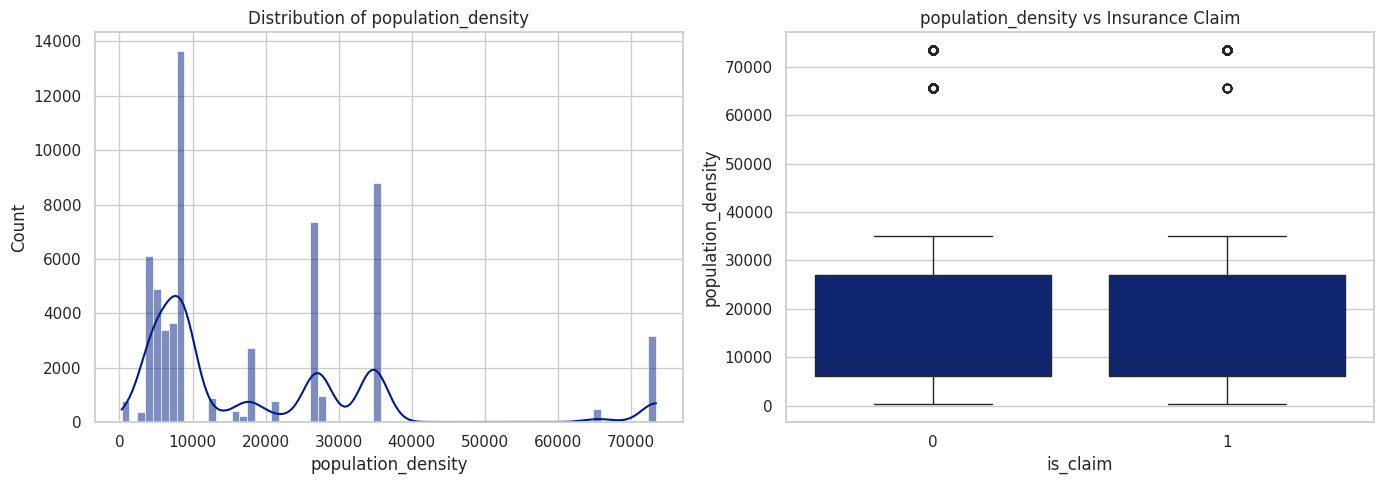

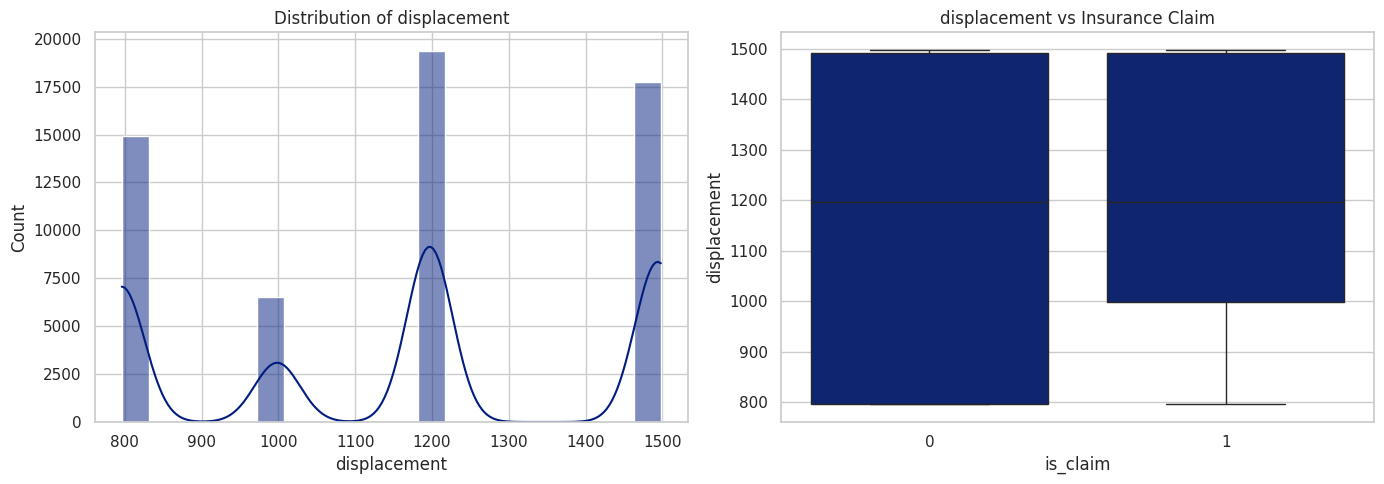

In [39]:
for col in ['population_density', 'displacement']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(train[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x='is_claim', y=col, data=train, ax=axes[1])
    axes[1].set_title(f"{col} vs Insurance Claim")

    plt.tight_layout()
    plt.show()


# ***Size & safety related Ploatting***


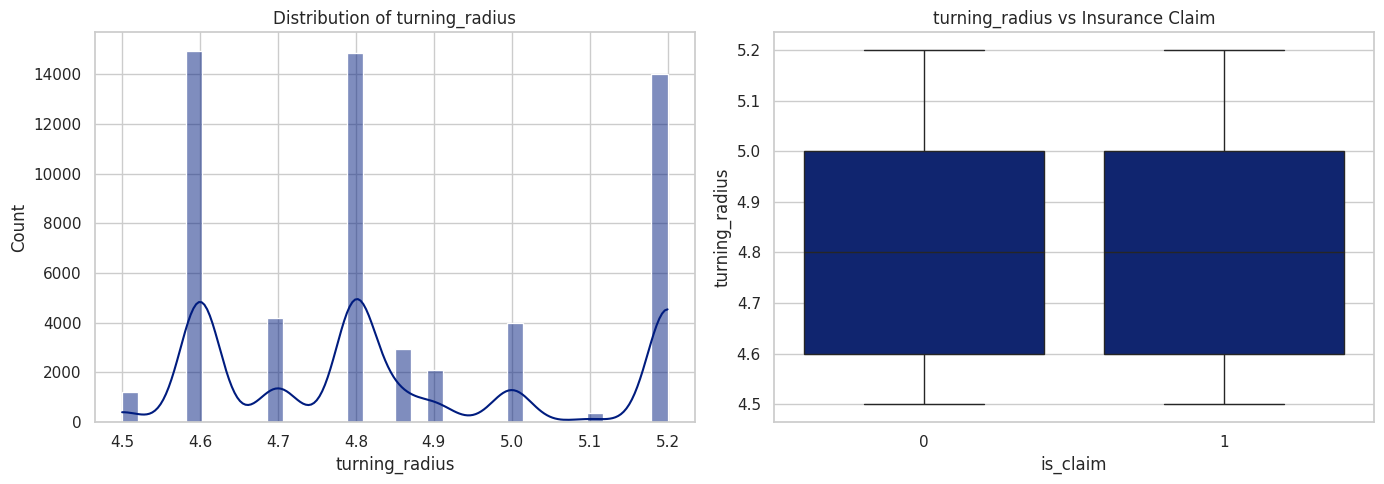

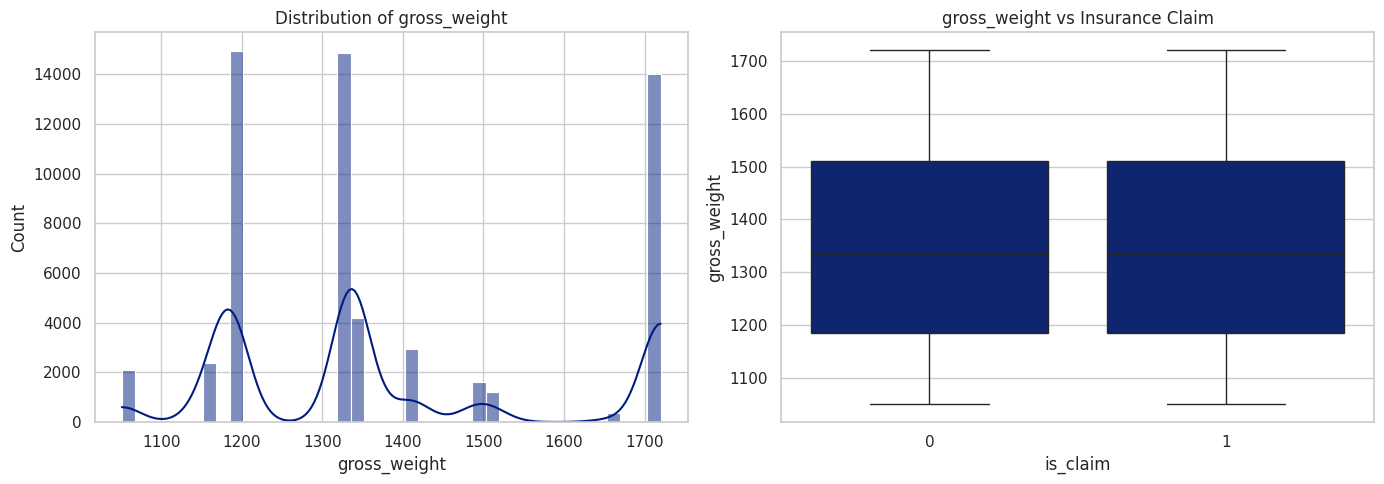

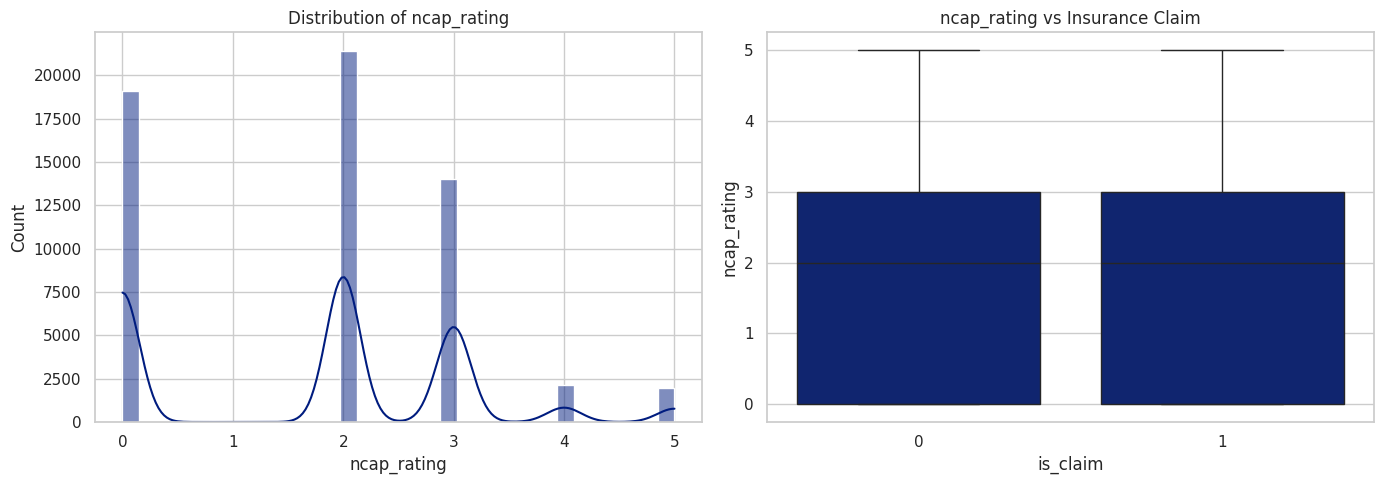

In [40]:
for col in ['turning_radius', 'gross_weight', 'ncap_rating']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(train[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x='is_claim', y=col, data=train, ax=axes[1])
    axes[1].set_title(f"{col} vs Insurance Claim")

    plt.tight_layout()
    plt.show()


# ***Numerical Attributes***





# *Segment*

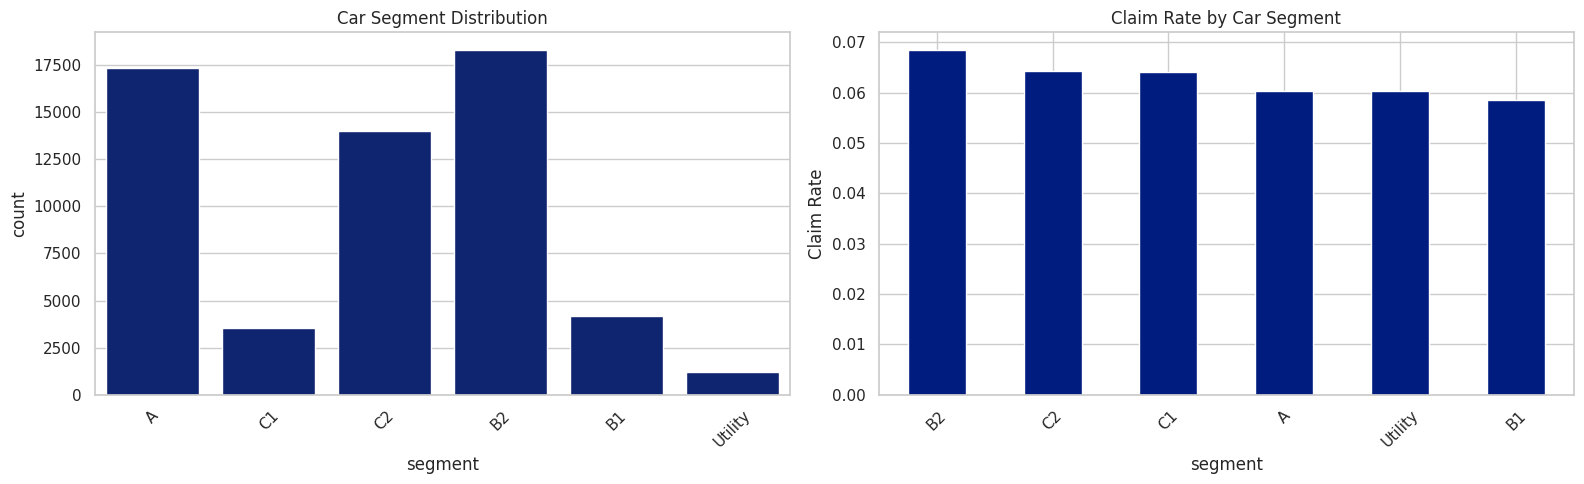

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


sns.countplot(x='segment', data=train, ax=axes[0])
axes[0].set_title("Car Segment Distribution")
axes[0].tick_params(axis='x', rotation=45)


segment_claim_rate = train.groupby('segment')['is_claim'].mean().sort_values(ascending=False)
segment_claim_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title("Claim Rate by Car Segment")
axes[1].set_ylabel("Claim Rate")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# *Fuel Type*

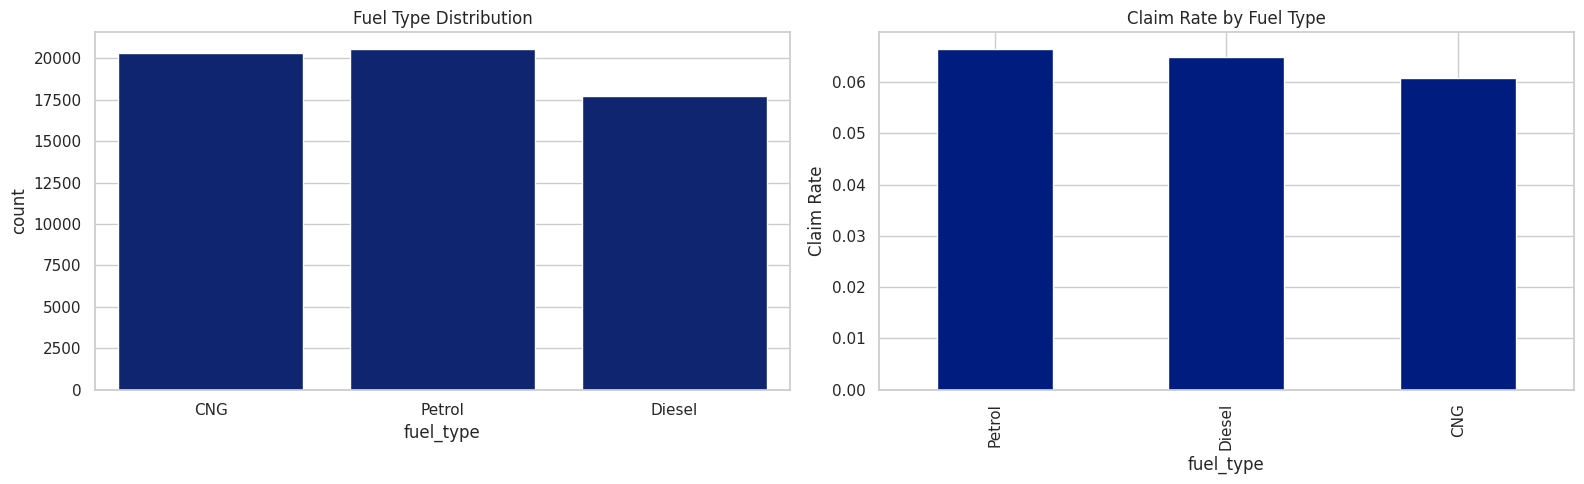

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x='fuel_type', data=train, ax=axes[0])
axes[0].set_title("Fuel Type Distribution")

fuel_claim_rate = train.groupby('fuel_type')['is_claim'].mean().sort_values(ascending=False)
fuel_claim_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title("Claim Rate by Fuel Type")
axes[1].set_ylabel("Claim Rate")

plt.tight_layout()
plt.show()


# *Transmission Type*

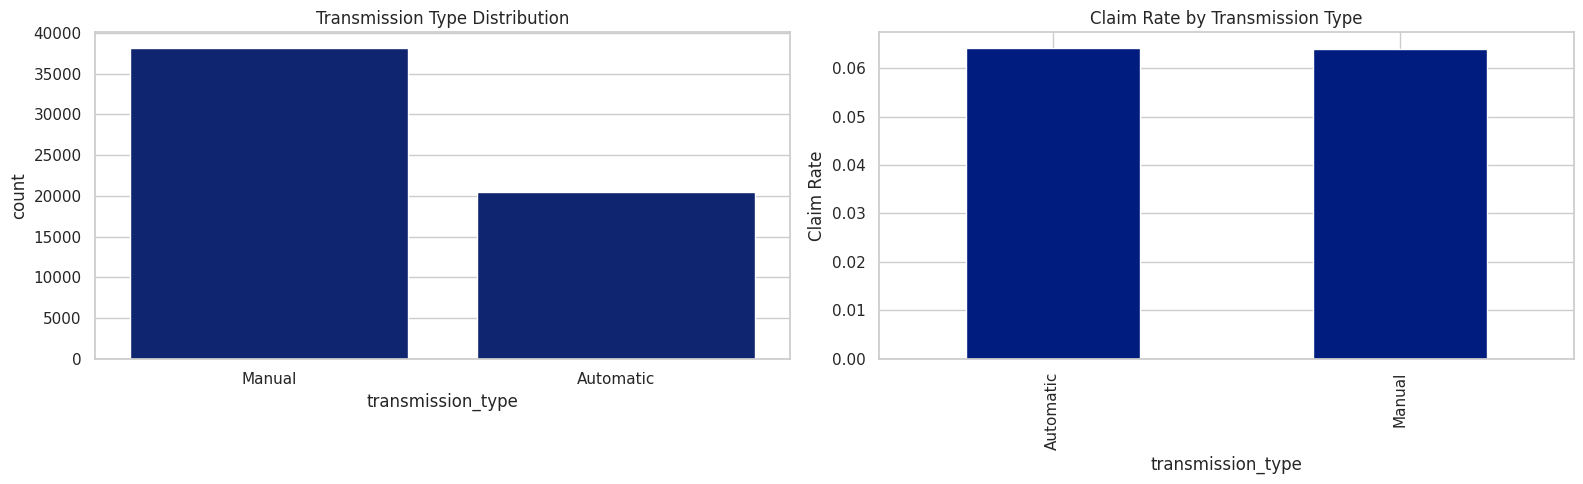

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x='transmission_type', data=train, ax=axes[0])
axes[0].set_title("Transmission Type Distribution")

fuel_claim_rate = train.groupby('transmission_type')['is_claim'].mean().sort_values(ascending=False)
fuel_claim_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title("Claim Rate by Transmission Type")
axes[1].set_ylabel("Claim Rate")

plt.tight_layout()
plt.show()

# *Rear Break Type*

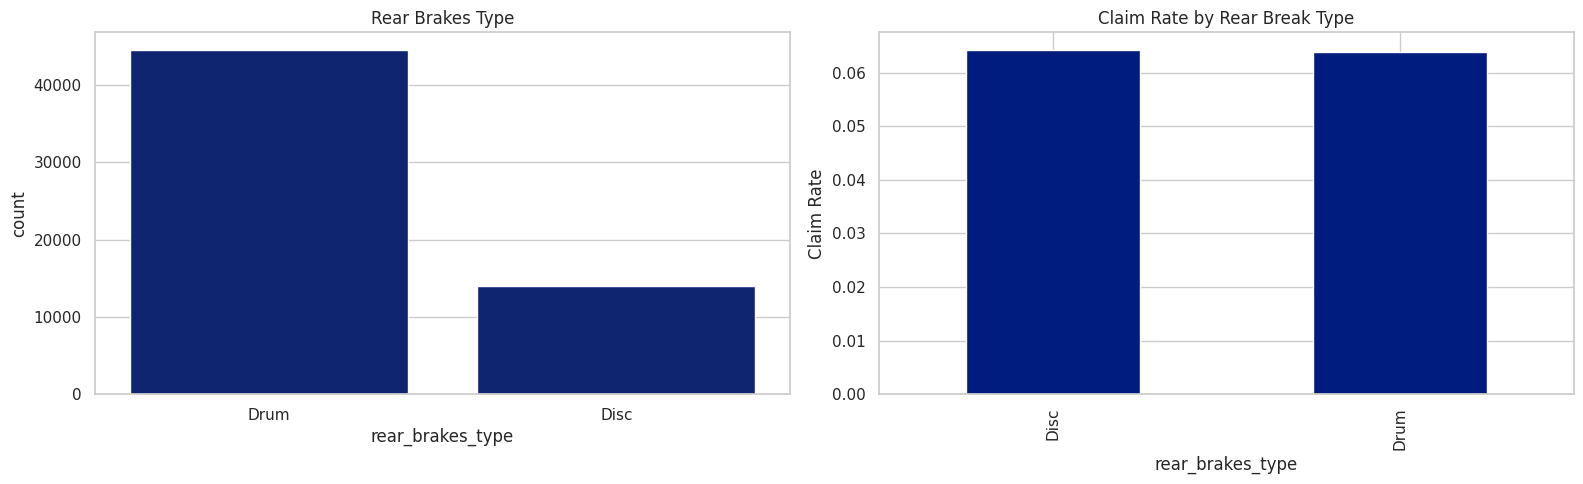

In [45]:
fig, axes = plt.subplots(1,2,figsize=(16,5))
sns.countplot(x = 'rear_brakes_type' , data=train , ax = axes[0])
axes[0].set_title('Rear Brakes Type')

rear_brakes_type_rate = train.groupby('rear_brakes_type')['is_claim'].mean().sort_values(ascending= False)
rear_brakes_type_rate.plot(kind = 'bar', ax = axes[1])
axes[1].set_title('Claim Rate by Rear Break Type')
axes[1].set_ylabel('Claim Rate')
plt.tight_layout()
plt.show()

# *Area Cluster*

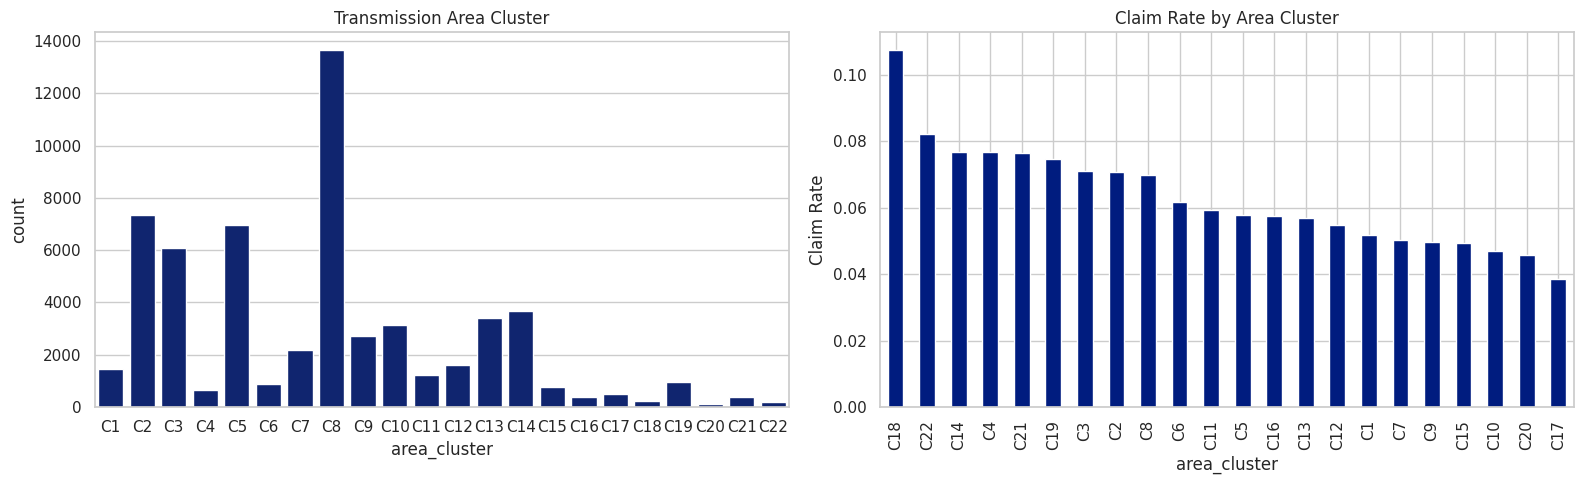

In [44]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x='area_cluster', data=train, ax=axes[0])
axes[0].set_title("Transmission Area Cluster")

fuel_claim_rate = train.groupby('area_cluster')['is_claim'].mean().sort_values(ascending=False)
fuel_claim_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title("Claim Rate by Area Cluster")
axes[1].set_ylabel("Claim Rate")

plt.tight_layout()
plt.show()

# *Number of Airbags*

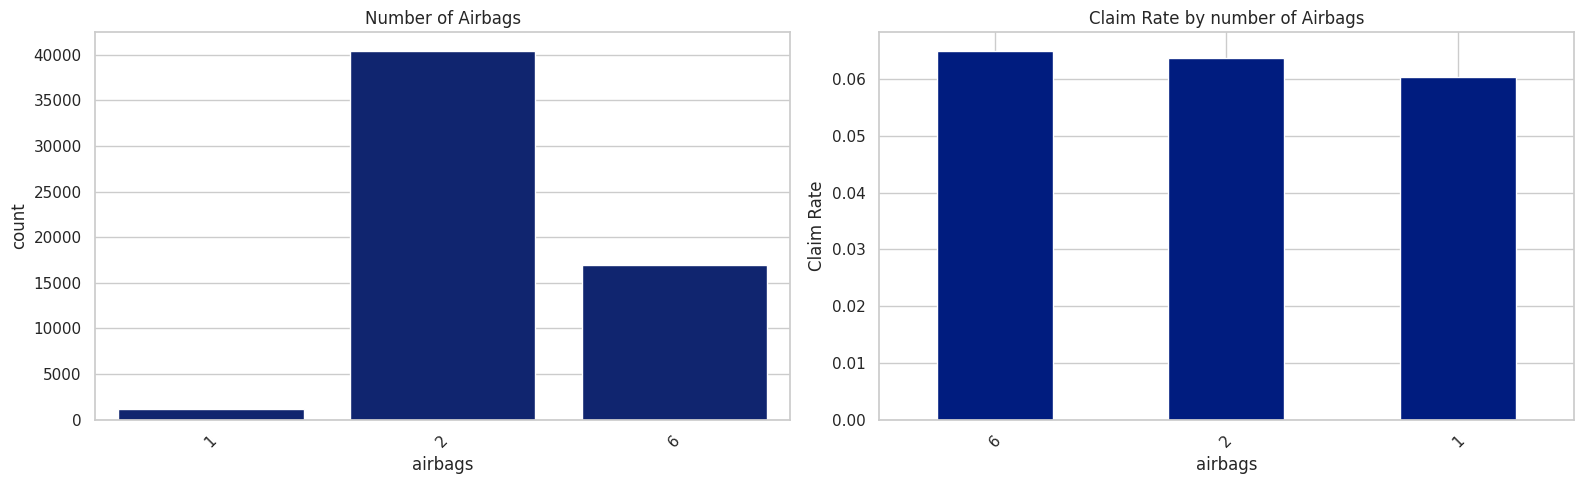

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


sns.countplot(x='airbags', data=train, ax=axes[0])
axes[0].set_title("Number of Airbags")
axes[0].tick_params(axis='x', rotation=45)


segment_claim_rate = train.groupby('airbags')['is_claim'].mean().sort_values(ascending=False)
segment_claim_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title("Claim Rate by number of Airbags")
axes[1].set_ylabel("Claim Rate")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ***Categorical Attributes***

# *ESC - Electronic Stability Control*

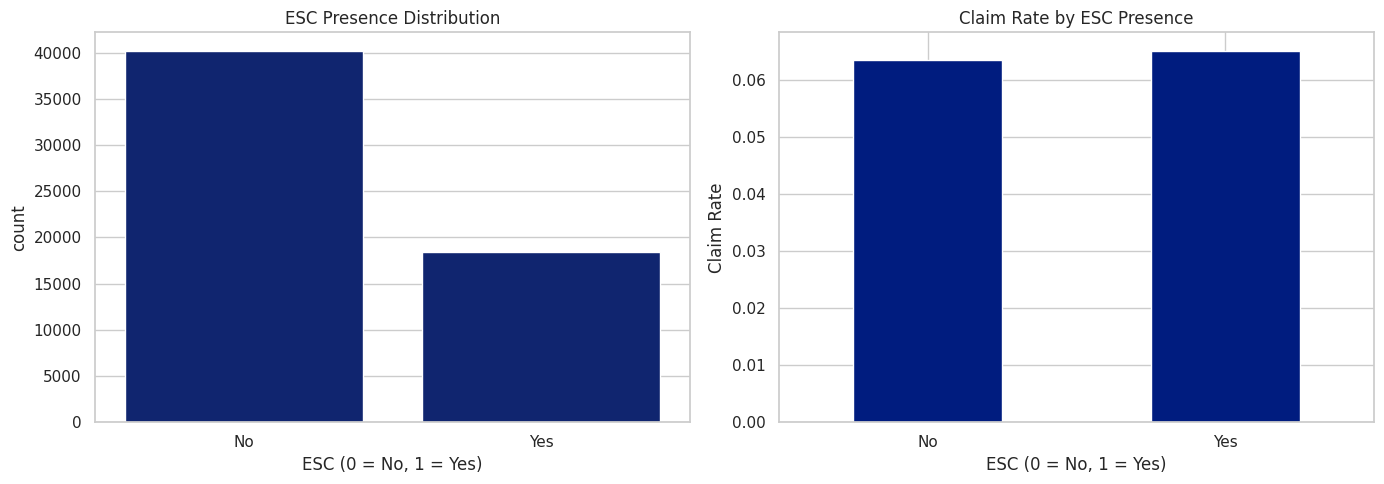

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='is_esc', data=train, ax=axes[0])
axes[0].set_title("ESC Presence Distribution")
axes[0].set_xlabel("ESC (0 = No, 1 = Yes)")

esc_claim_rate = train.groupby('is_esc')['is_claim'].mean()
esc_claim_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title("Claim Rate by ESC Presence")
axes[1].set_ylabel("Claim Rate")
axes[1].set_xlabel("ESC (0 = No, 1 = Yes)")
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()


# *Tyre Pressure Monitoring System Presence*

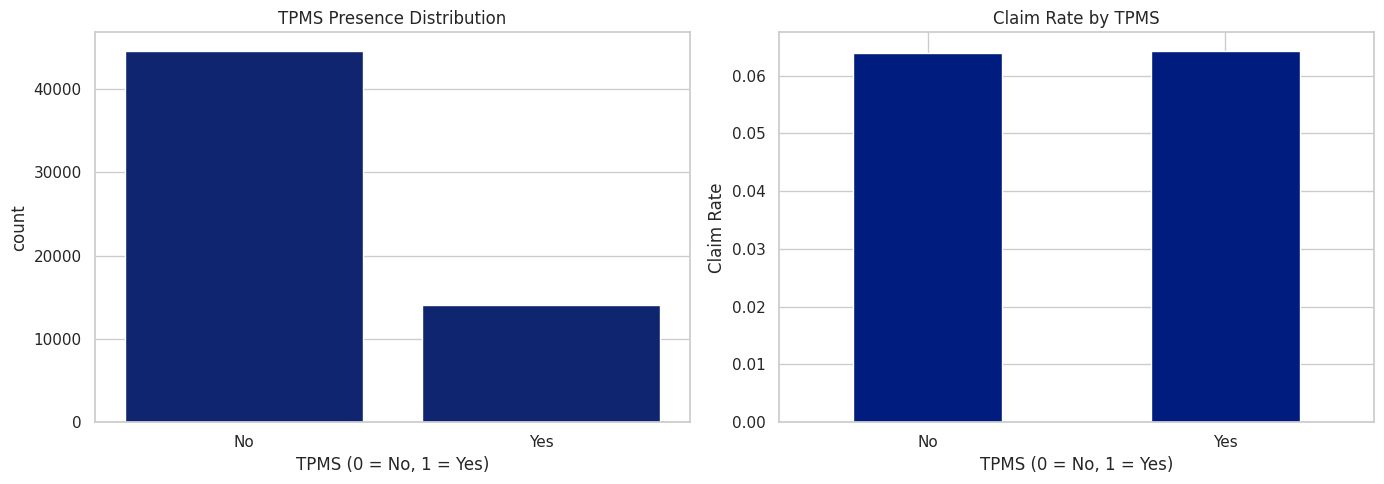

In [52]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(x='is_tpms', data=train, ax=axes[0])
axes[0].set_title("TPMS Presence Distribution")
axes[0].set_xlabel("TPMS (0 = No, 1 = Yes)")


esc_claim_rate = train.groupby('is_tpms')['is_claim'].mean()
esc_claim_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title("Claim Rate by TPMS")
axes[1].set_ylabel("Claim Rate")
axes[1].set_xlabel("TPMS (0 = No, 1 = Yes)")
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()


# *Break Assistance*

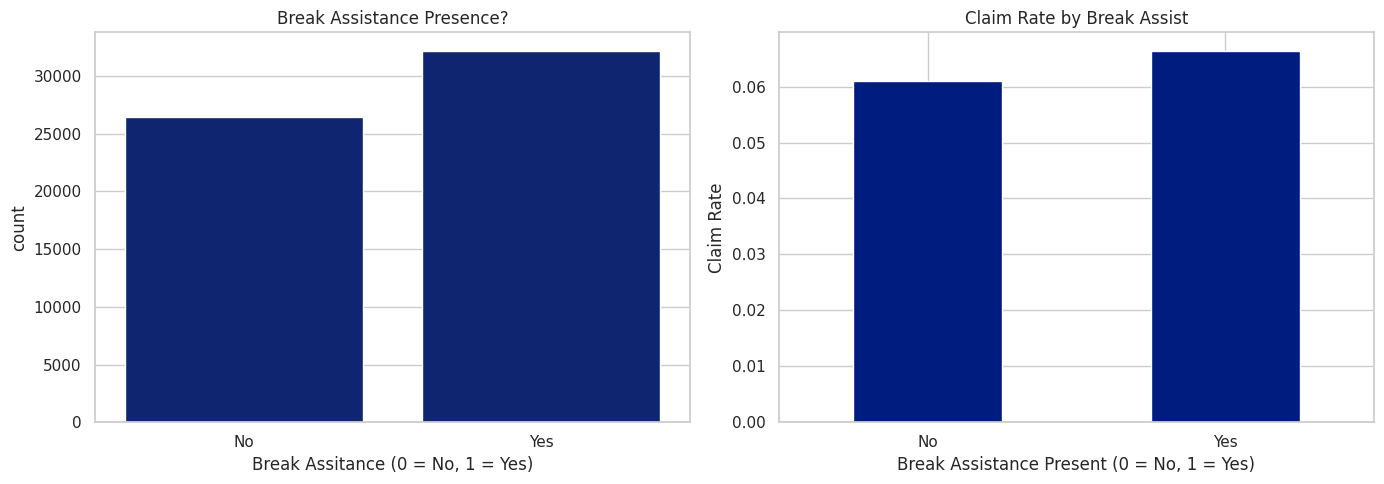

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(x='is_brake_assist', data=train, ax=axes[0])
axes[0].set_title("Break Assistance Presence?")
axes[0].set_xlabel("Break Assitance (0 = No, 1 = Yes)")


esc_claim_rate = train.groupby('is_brake_assist')['is_claim'].mean()
esc_claim_rate.plot(kind='bar', ax=axes[1])
axes[1].set_title("Claim Rate by Break Assist")
axes[1].set_ylabel("Claim Rate")
axes[1].set_xlabel("Break Assistance Present (0 = No, 1 = Yes)")
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()


## ***Corelation Heatmap***

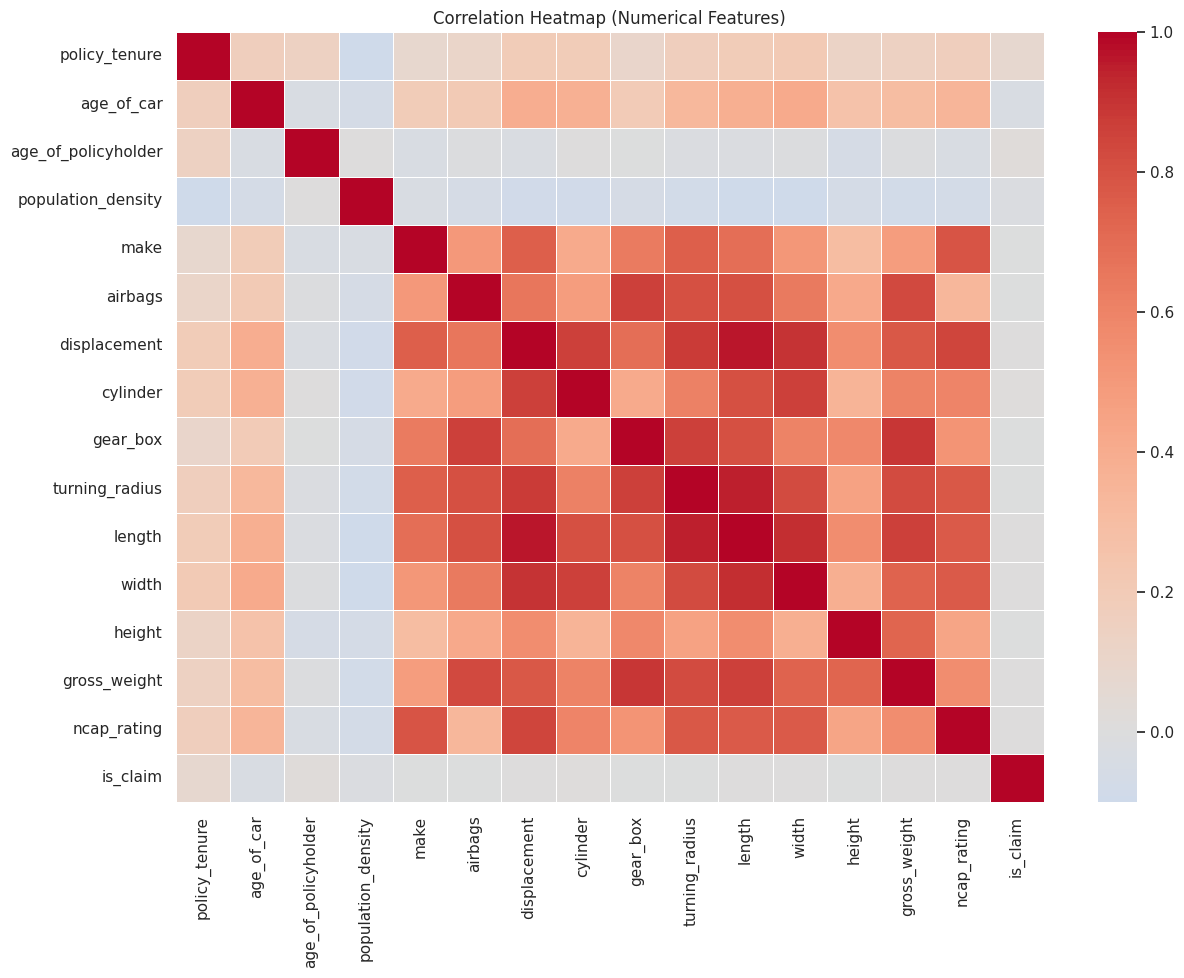

In [59]:
num_cols = train.select_dtypes(include=['int64', 'float64'])


corr = num_cols.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()